# ChemAI: Predict the Cure


In [30]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, RobustScaler

RANDOM_STATE = 42

## Загрузка данных

Данные читаются напрямую из папки датасета Kaggle. В коде нет поиска файлов и универсальных проверок: путь задан явно для этого соревнования.

In [31]:
DATA_PATH = '/kaggle/input/datasets/ilya1985/testdata'

train_df = pd.read_csv(f'{DATA_PATH}/train.csv')
test_df = pd.read_csv(f'{DATA_PATH}/test.csv')
sample_submission = pd.read_csv(f'{DATA_PATH}/sample_submission.csv')

train_df = train_df.drop(columns=['index'])
test_index = sample_submission['index']
test_df = test_df.drop(columns=['index'])

In [32]:
pd.set_option('display.max_columns', None)

print(train_df.shape)
print(test_df.shape)

display(train_df.head())
display(train_df.describe())

(751, 213)
(250, 210)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,102.414420,95.757483,0.935000,5.466584,5.466584,0.719259,0.719259,0.681165,18.307692,195.287,182.183,195.071785,70,0,0.119177,-0.360247,0.360247,0.119177,1.230769,2.076923,2.923077,32.166506,10.291948,2.082825,-2.203512,2.178787,-2.230562,7.988993,0.155539,2.471240,2.063714,244.361475,8.932875,7.478889,8.295385,6.466326,4.421446,5.576147,2.950079,4.024775,1.987598,2.937188,1.292489,2.101284,-0.67,1.789178e+03,8.907639,4.533756,2.386264,82.881829,9.636773,6.730817,0.000000,0.000000,0.000000,0.000000,0.000,0.000000,0.000000,11.761885,18.199101,12.132734,11.440240,12.483670,4.736863,17.449271,0.0,0.000000,0.000000,0.000000,29.867250,30.331835,0,0.000000,4.899910,5.687386,0.000000,11.761885,24.967341,4.736863,0.000000,0.000000,30.331835,0.000000,0.000000,0,12.47,0.000000,0.000000,0.0,0.000000,0.000000,24.967341,5.687386,0.000000,17.828252,29.165378,4.736863,5.466584,1.919608,2.247685,0.000000,1.247130,2.132289,10.398397,0.000000,1.588307,0.000000,0.400000,13,0,2,0,1,1,1,0,1,3,0,3,1,0,1,1,2,2.1714,57.0650,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,0.044333,8.401080,189.500000,11.492712,11.492712,0.012350,-3.798024,0.769122,27.652174,360.907,335.707,360.127441,130,0,0.237676,-0.393087,0.393087,0.237676,1.304348,1.956522,2.521739,35.495692,9.631497,2.400142,-2.449813,2.456783,-2.415599,7.887726,-0.003171,2.314947,2.157249,690.565805,17.466255,13.76

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,MaxPartialCharge,MinPartialCharge,MaxAbsPartialCharge,MinAbsPartialCharge,FpDensityMorgan1,FpDensityMorgan2,FpDensityMorgan3,BCUT2D_MWHI,BCUT2D_MWLOW,BCUT2D_CHGHI,BCUT2D_CHGLO,BCUT2D_LOGPHI,BCUT2D_LOGPLOW,BCUT2D_MRHI,BCUT2D_MRLOW,AvgIpc,BalabanJ,BertzCT,Chi0,Chi0n,Chi0v,Chi1,Chi1n,Chi1v,Chi2n,Chi2v,Chi3n,Chi3v,Chi4n,Chi4v,HallKierAlpha,Ipc,Kappa1,Kappa2,Kappa3,LabuteASA,PEOE_VSA1,PEOE_VSA10,PEOE_VSA11,PEOE_VSA12,PEOE_VSA13,PEOE_VSA14,PEOE_VSA2,PEOE_VSA3,PEOE_VSA4,PEOE_VSA5,PEOE_VSA6,PEOE_VSA7,PEOE_VSA8,PEOE_VSA9,SMR_VSA1,SMR_VSA10,SMR_VSA2,SMR_VSA3,SMR_VSA4,SMR_VSA5,SMR_VSA6,SMR_VSA7,SMR_VSA8,SMR_VSA9,SlogP_VSA1,SlogP_VSA10,SlogP_VSA11,SlogP_VSA12,SlogP_VSA2,SlogP_VSA3,SlogP_VSA4,SlogP_VSA5,SlogP_VSA6,SlogP_VSA7,SlogP_VSA8,SlogP_VSA9,TPSA,EState_VSA1,EState_VSA10,EState_VSA11,EState_VSA2,EState_VSA3,EState_VSA4,EState_VSA5,EState_VSA6,EState_VSA7,EState_VSA8,EState_VSA9,VSA_EState1,VSA_EState10,VSA_EState2,VSA_EState3,VSA_EState4,VSA_EState5,VSA_EState6,VSA_EState7,VSA_EState8,VSA_EState9,FractionCSP3,HeavyAtomCount,NHOHCount,NOCount,NumAliphaticCarbocycles,NumAliphaticHeterocycles,NumAliphaticRings,NumAromaticCarbocycles,NumAromaticHeterocycles,NumAromaticRings,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR,fr_Al_COO,fr_Al_OH,fr_Al_OH_noTert,fr_ArN,fr_Ar_COO,fr_Ar_N,fr_Ar_NH,fr_Ar_OH,fr_COO,fr_COO2,fr_C_O,fr_C_O_noCOO,fr_C_S,fr_HOCCN,fr_Imine,fr_NH0,fr_NH1,fr_NH2,fr_N_O,fr_Ndealkylation1,fr_Ndealkylation2,fr_Nhpyrrole,fr_SH,fr_aldehyde,fr_alkyl_carbamate,fr_alkyl_halide,fr_allylic_oxid,fr_amide,fr_amidine,fr_aniline,fr_aryl_methyl,fr_azide,fr_azo,fr_barbitur,fr_benzene,fr_benzodiazepine,fr_bicyclic,fr_diazo,fr_dihydropyridine,fr_epoxide,fr_ester,fr_ether,fr_furan,fr_guanido,fr_halogen,fr_hdrzine,fr_hdrzone,fr_imidazole,fr_imide,fr_isocyan,fr_isothiocyan,fr_ketone,fr_ketone_Topliss,fr_lactam,fr_lactone,fr_methoxy,fr_morpholine,fr_nitrile,fr_nitro,fr_nitro_arom,fr_nitro_arom_nonortho,fr_nitroso,fr_oxazole,fr_oxime,fr_para_hydroxylation,fr_phenol,fr_phenol_noOrthoHbond,fr_phos_acid,fr_phos_ester,fr_piperdine,fr_piperzine,fr_priamide,fr_prisulfonamd,fr_pyridine,fr_quatN,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,749.000000,749.000000,749.000000,749.000000,751.000000,751.000000,751.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,749.000000,751.000000,7.510000e+02,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,7.510000e+02,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.0,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751.000000,751

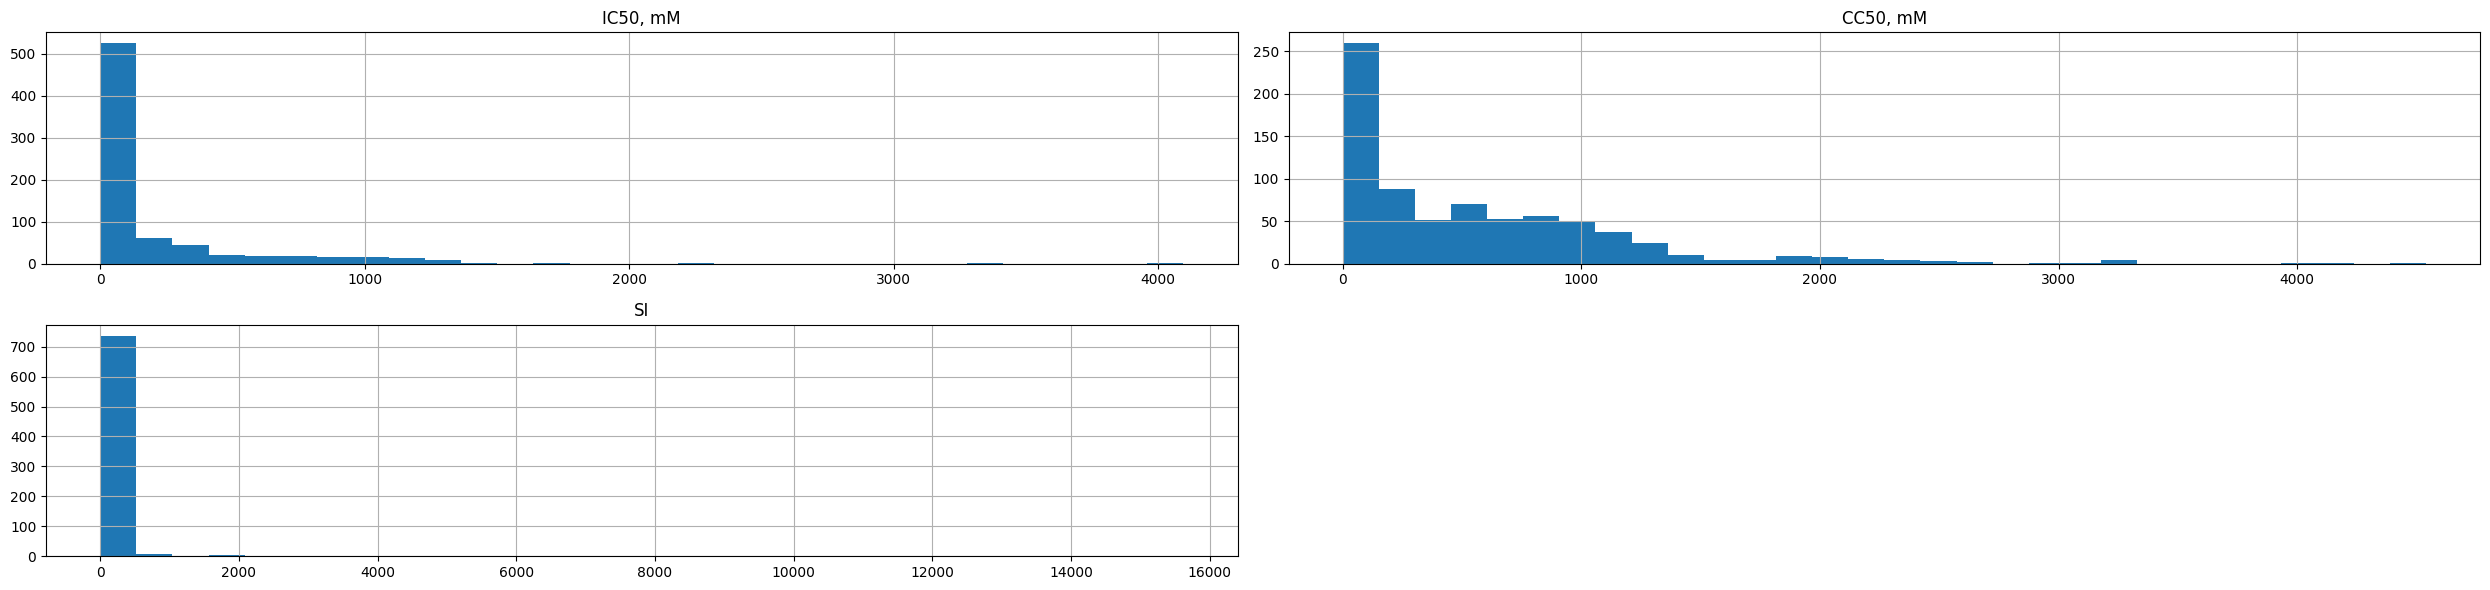

In [41]:
targets = ['IC50, mM', 'CC50, mM', 'SI']

train_df[targets].hist(bins=30, figsize=(25, 6))
plt.tight_layout()
plt.show()

**Вывод по анализу данных.**  
В обучающей выборке есть молекулярные дескрипторы и три целевых показателя. Целевые переменные положительные и распределены неравномерно, поэтому для `IC50` и `SI` используется степенное преобразование, а для `CC50` — устойчивое масштабирование.

## Подготовка признаков

Из признаков исключаются только целевые столбцы. Пропуски заполняются медианой, так как это устойчивый вариант для табличных химических дескрипторов.

In [34]:
all_features = [col for col in train_df.columns if col not in targets]

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(train_df[all_features])
X_test = imputer.transform(test_df[all_features])

In [35]:
lower_si = train_df['SI'].quantile(0.01)
upper_si = train_df['SI'].quantile(0.99)
mask_si = (train_df['SI'] >= lower_si) & (train_df['SI'] <= upper_si)
train_si = train_df[mask_si]

print('До фильтрации SI:', train_df.shape[0])
print('После фильтрации SI:', train_si.shape[0])

До фильтрации SI: 751
После фильтрации SI: 735


**Вывод по предобработке.**  
Для всех моделей используется один и тот же набор дескрипторов и одинаковая медианная импутация. Для `SI` дополнительно удаляется по 1% крайних значений, потому что этот показатель сильнее всего зависит от выбросов.

## Модель для IC50

Для `IC50` используется `PowerTransformer`, так как целевая переменная имеет выраженную асимметрию.


In [36]:
pt_ic50 = PowerTransformer(method='box-cox')
y_ic50 = pt_ic50.fit_transform(train_df[['IC50, mM']].values).ravel()

rf_ic50 = RandomForestRegressor(
    max_depth=None,
    min_samples_leaf=3,
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_ic50.fit(X_train, y_ic50)
pred_ic50 = pt_ic50.inverse_transform(rf_ic50.predict(X_test).reshape(-1, 1)).ravel()

## Модель для CC50

Для `CC50` используется `RobustScaler`, потому что целевая переменная имеет крупные значения и выбросы. Такой вариант сохраняет исходную шкалу, но снижает влияние экстремальных наблюдений при обучении.

In [37]:
rs_cc50 = RobustScaler()
y_cc50 = rs_cc50.fit_transform(train_df[['CC50, mM']].values).ravel()

rf_cc50 = RandomForestRegressor(
    max_depth=None,
    min_samples_leaf=3,
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_cc50.fit(X_train, y_cc50)
pred_cc50 = rs_cc50.inverse_transform(rf_cc50.predict(X_test).reshape(-1, 1)).ravel()

## Модель для SI

Для `SI` используется отдельная модель. Перед обучением удаляется по 1% крайних значений, чтобы модель меньше подстраивалась под редкие экстремальные соединения.

In [38]:
X_train_si = X_train[mask_si.values]

pt_si = PowerTransformer(method='box-cox')
y_si = pt_si.fit_transform(train_si[['SI']].values).ravel()

rf_si = RandomForestRegressor(
    max_depth=10,
    min_samples_leaf=1,
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_si.fit(X_train_si, y_si)
pred_si = pt_si.inverse_transform(rf_si.predict(X_test).reshape(-1, 1)).ravel()

**Вывод по обучению.**  
Для всех трёх показателей выбран `RandomForestRegressor`, но с разной обработкой целевой переменной. Такой подход сохраняет простую структуру решения и позволяет учитывать особенности каждого таргета отдельно.

## Предсказание и файл для Kaggle

На последнем этапе собирается таблица в формате `sample_submission`: `index`, `IC50`, `CC50`, `SI`.

In [42]:
submission = pd.DataFrame({
    'index': test_index,
    'IC50': pred_ic50,
    'CC50': pred_cc50,
    'SI': pred_si,
})

submission.to_csv('submission.csv', index=False)

## Общий вывод

В решении используется простая и воспроизводимая схема: медианное заполнение пропусков, отдельная обработка каждого целевого показателя и три модели `RandomForestRegressor`.  

`IC50` и `SI` предварительно преобразуются через `PowerTransformer`, так как эти величины имеют выраженную асимметрию. Для `CC50` применяется `RobustScaler`, поскольку этот показатель содержит крупные значения и чувствителен к выбросам. Для `SI` дополнительно удаляются крайние 1% значений, что делает модель устойчивее.


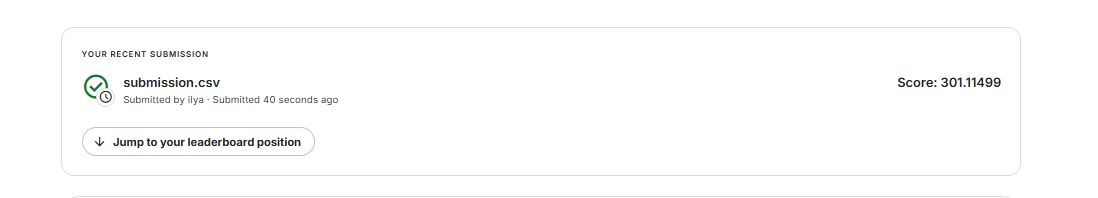